In [66]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns
import random

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

aln.params.de = 0.
aln.params.di = 0.
aln.params.signalV = 0.

state_vars = aln.state_vars
init_vars = aln.init_vars

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]

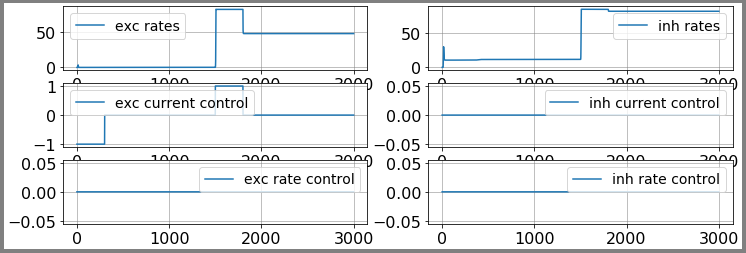

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]

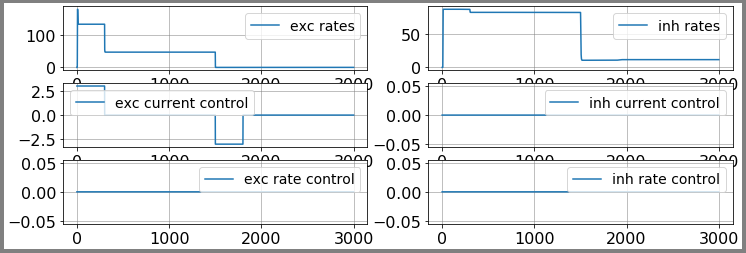

low state vars =  [ 8.2469e-02  1.1638e+01  4.3314e-01  7.5957e-01  0.0000e+00  1.6029e-02
  6.3812e-01  1.4997e-02  7.8014e-01  9.5893e-04  6.6523e-03  8.4016e-04
  6.5247e-03  0.0000e+00  0.0000e+00  7.1463e-01  5.5403e-01 -5.6298e+01
  2.7100e+01  6.3823e+00]


In [4]:
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]

print("low state vars = ", low_state_vars)

In [58]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 50

initVars = low_state_vars

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 
                    0.8, 0.8, 0.8, 0.8, 0.8 ]

sheet = "line_search"

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])

In [59]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl        

In [135]:
def setrandomcontrol(control_, max_cntrl_, min_cntrl_, cntrl_vars_):
    for n in range(control_.shape[0]):
        for v in range(control_.shape[1]):
            if v in cntrl_vars_:
                mean_cntrl = np.mean( [max_cntrl_[v], min_cntrl_[v]] )
                control_[n,v,1] = mean_cntrl
                for t in range(2, control_.shape[2]-1):
                    control_[n,v,t] = control_[n,v,t-1] + 0.01 * mean_cntrl * random.uniform(-1, 1)
                    
    return control_

## 0

ERROR:root:Problem in initial value trasfer


set cost params
control input:  [4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6771.428488547636
Gradient descend method:  None
RUN  0 , total integrated cost =  6771.428488547636
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -58.66146515300276 -58.65291203699422


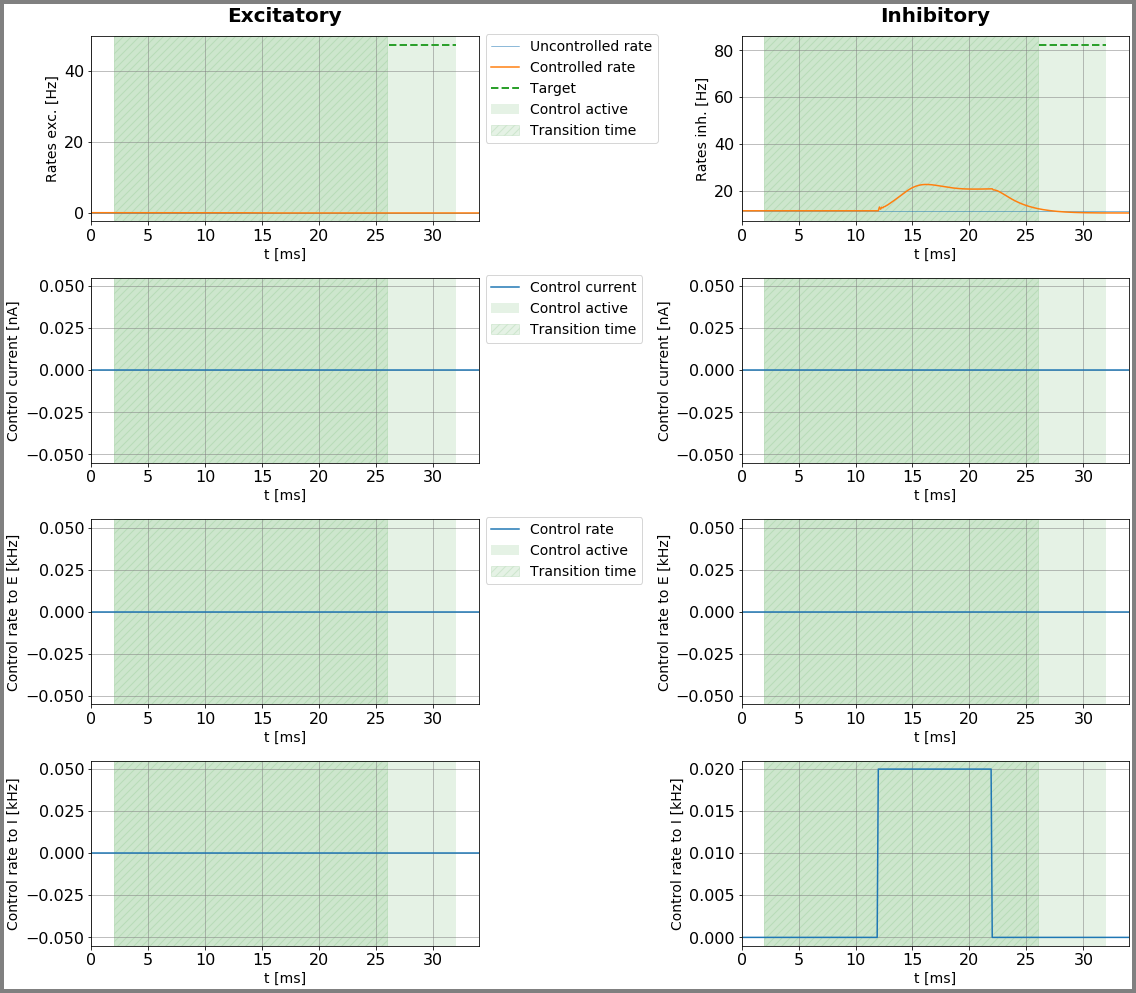

In [143]:
# A.0.a)

dur = 30.
dur_pre = 2.
dur_post = 2.
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = [4,5] #c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
control0[0,5,100:200] = 0.02
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = None
max_it = 0

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada, phia = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    line_search_ = None, control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

#plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [3, 4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.2758695790554255
Gradient descend method:  None
RUN  1 , total integrated cost =  3.2758695790554255
Control only changes marginally.
RUN  1 , total integrated cost =  3.2758695790554255
Improved over  1  iterations in  0.15402580000227317  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmai_f 0.5540255416344957 0.5540254642905454
Problem in initial value trasfer:  tau_inh 6.382311313220983 6.382311585055631
Problem in initial value trasfer:  sigmae_f 0.50559931159141 0.5053108153622017
Problem in initial value trasfer:  Vmean_exc -56.18084660221543 -56.18096852029587


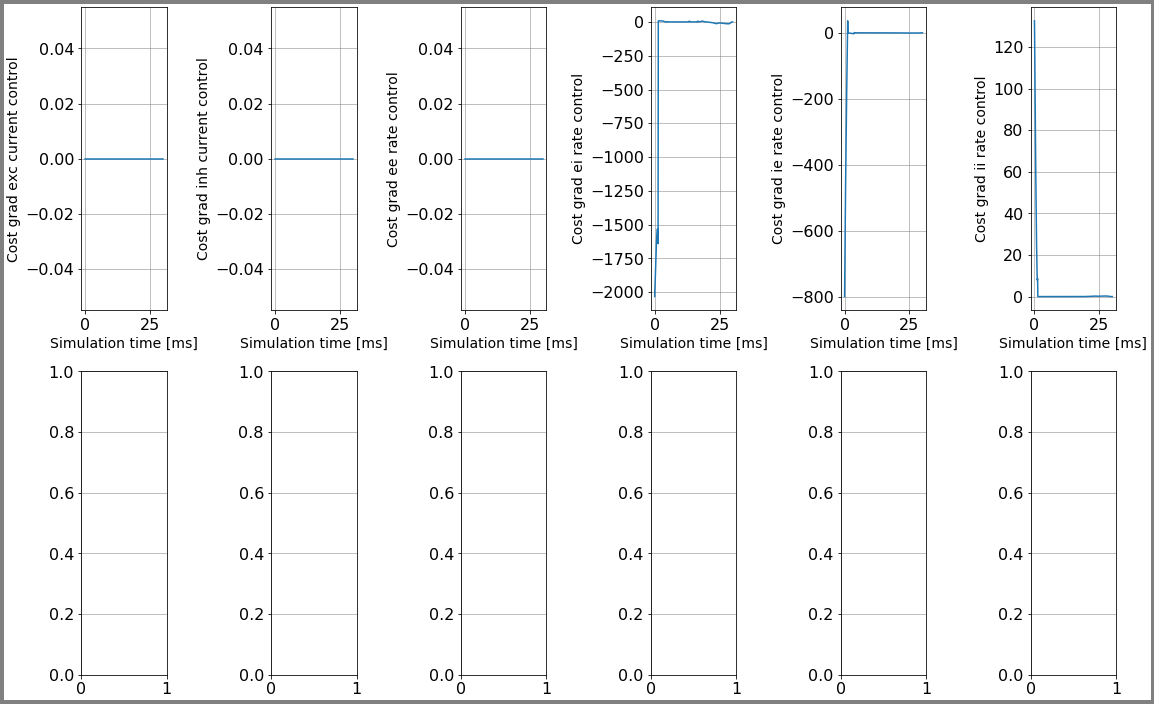

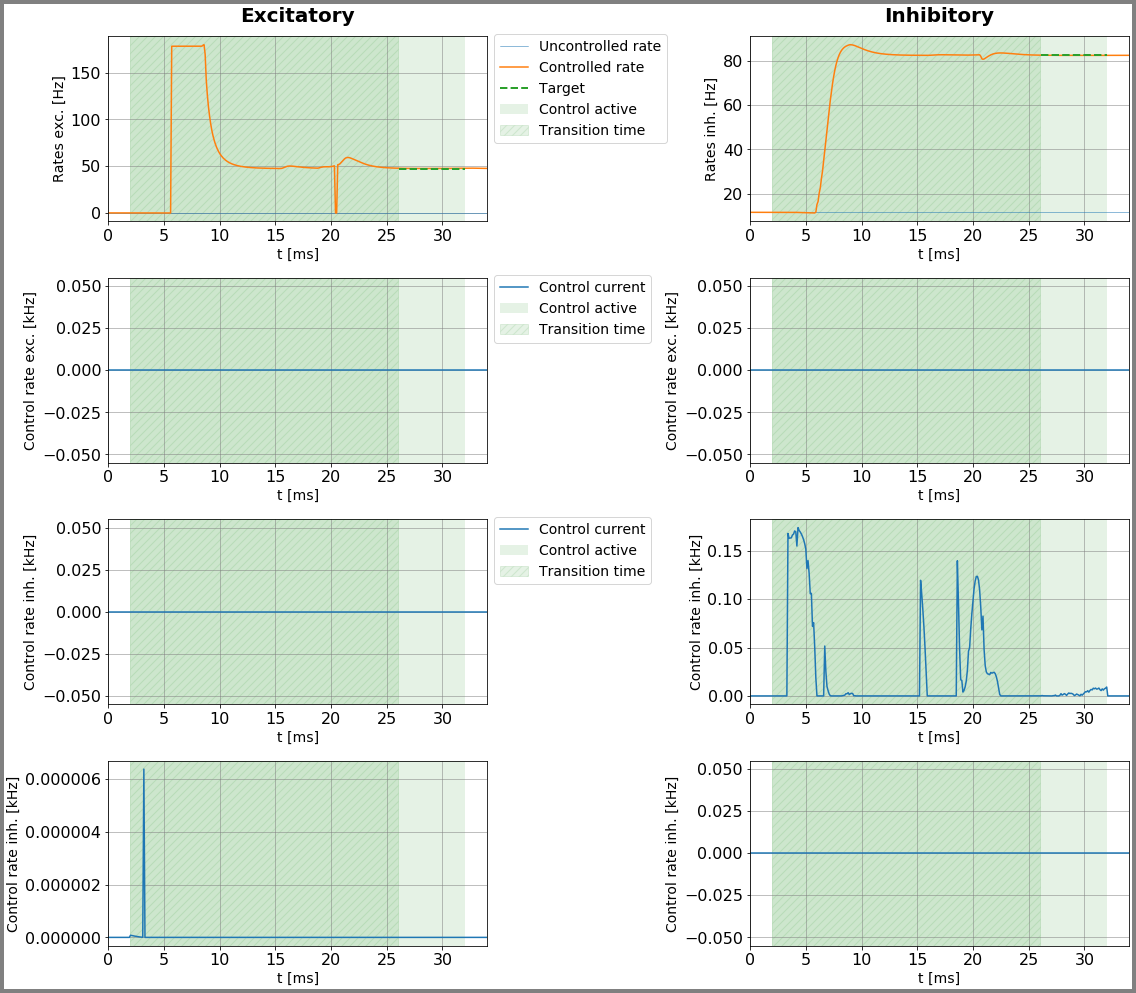

In [102]:
case_ind = 0
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 10.0, 10.0)
cntrl_vars = [3,4,5] #c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#print(control0[0,3,:])
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = None
max_it = 10

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb, bestStateb, costb, runtimeb, gradb, phib = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    line_search_ = None, control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )